In [35]:
from pathlib import Path
from typing import Any
import numpy as np
import optuna
from dataclasses import dataclass

from my_types import Quat, ScalarBatch, Vec3Batch, QuatBatch
from io_csv import load_gyro_base, load_ref, load_acc, load_mag, load_grav_ref, load_acc_lin_ref, read_best_exp2_from_log
from pipelines import generate_m_ref_world_h_unit, integrate_gyro_acc_mag
from evaluation import calc_angle_err, print_err_status, save_err_csv, plot_err_from_csv, plot_err_colored_by_weight
from evaluation import save_estimated_vec3_csv, evaluate_estimated_vec3_autosign, calc_vec3_direction_angle_err
from resample import find_stable_start_idx, cut_sample
from autotune import auto_setup_imu_frame, quasi_static_detector, suggest_fixed_gate_sigma
from optuna_exp_3 import exp_3_1, exp_3_2, exp_3_3, exp_3_4, exp_3_5, exp_3_6
from Tee import Tee

SIGMA_FLOOR: float = 1e-3
EPS: float = 1e-9

In [36]:
sample_1: str = "data01_21:08_oct_07_2025_5min"
sample_2: str = "data02_21:23_oct_07_2025_9min"
sample_3: str = "data03_21:41_oct_07_2025_13min"
sample_4: str = "data04_18:52_oct_08_2025_96min"

sample: str = sample_3

root: Path = Path.cwd().parent
run_dir: Path = root / "data" / sample

ori_path: Path = run_dir / "Orientation.csv"
gyro_path: Path = run_dir / "Gyroscope.csv"
acc_path: Path = run_dir / "AccelerometerUncalibrated.csv"
mag_path: Path = run_dir / "Magnetometer.csv"
grav_path: Path = run_dir / "Gravity.csv"
acc_lin_path: Path = run_dir / "Accelerometer.csv"

for p in [ori_path, gyro_path, acc_path, mag_path, grav_path, acc_lin_path]:
        if not p.exists():
                raise FileNotFoundError(f"File not found: {p}")

out_dir: Path = root / "output" / sample
out_dir.mkdir(parents=True, exist_ok=True)

path_log: Path = out_dir / "03_exp3_log.txt"
path_err_1: Path = out_dir / "03_exp3-1_angle_err.csv"
path_err_2: Path = out_dir / "03_exp3-2_angle_err.csv"
path_err_3: Path = out_dir / "03_exp3-3_angle_err.csv"
path_err_4: Path = out_dir / "03_exp3-4_angle_err.csv"
path_err_5: Path = out_dir / "03_exp3-5_angle_err.csv"
path_err_6: Path = out_dir / "03_exp3-6_angle_err.csv"

path_plot: Path = out_dir / "03_exp3_plot.png"
path_plot_weight: Path = out_dir / "03_exp3_plot_weight.png"

path_est_grav: Path = out_dir / "03_exp3_grav_est.csv"
path_est_acc: Path = out_dir / "03_exp3_acc_lin_est.csv"


for p in [path_log, path_err_1, path_err_2, path_err_3, path_err_4, path_err_5, path_err_6,
          path_plot, path_plot_weight, path_est_grav, path_est_acc]:
        if p.is_file():
                p.unlink()

In [37]:
with Tee(path_log):
        t_src_gyro, w_src_gyro, dt, t_new, w_avg_gyro = load_gyro_base(gyro_path)

        q_ref_interp = load_ref(ori_path, t_new)
        q_ref_interp /= np.linalg.norm(q_ref_interp, axis=1, keepdims=True)

        g_ref_interp = load_grav_ref(grav_path, t_new)
        a_lin_ref_interp = load_acc_lin_ref(acc_lin_path, t_new)

        idx_cut: int = find_stable_start_idx(dt, w_avg_gyro, q_ref_interp,
                                             sample_window=1000, threshold=0.5, sample_hz=100,
                                             consecutive=3, min_cut_second=10, max_cut_second=30)
        t_cut: int = idx_cut / 100
        a_src_interp = load_acc(acc_path, t_new)
        m_src_interp = load_mag(mag_path, t_new)
        [dt, t_new, w_avg_gyro, q_ref_interp,
         a_src_interp, m_src_interp,
         g_ref_interp, a_lin_ref_interp] = cut_sample(idx_cut,
                                                      [dt, t_new, w_avg_gyro, q_ref_interp,
                                                       a_src_interp, m_src_interp,
                                                       g_ref_interp, a_lin_ref_interp])



[START] 2026-03-16 16:36:31.122

[OK] Stabilization detected, cut idx 2300 (≈ 23.0s)

[END] 2026-03-16 16:36:33.739




In [38]:
with Tee(path_log):
        q0: Quat = q_ref_interp[0].copy()
        g0: float = 9.80665
        a_src_interp, g_world_unit = auto_setup_imu_frame(q_ref_interp, w_avg_gyro, dt,
                                                          g0, a_src_interp)
        print("")

        m0: float = np.median(np.linalg.norm(m_src_interp, axis=1))
        m_ref_world_h_unit = generate_m_ref_world_h_unit(g0, g_world_unit, 5000,
                                                         q_ref_interp, a_src_interp, m_src_interp)
        
        best_quasi_static = quasi_static_detector(w_avg_gyro, a_src_interp, dt, g0,
                                                  w_thr=4, a_thr=4,
                                                  min_duration_s=0.5, smooth_win=5)
        print("")

        gyro_gate_sigma, acc_gate_sigma, mag_gate_sigma = suggest_fixed_gate_sigma(
                                                                w_avg_gyro, a_src_interp, m_src_interp,
                                                                g0, m0,
                                                                p_gyro=90, p_acc=90, p_mag=90, sigma_floor=SIGMA_FLOOR,
                                                                best_quasi_static=best_quasi_static)



[START] 2026-03-16 16:36:33.754

Detected accel unit in [m/s²]
Selected g_world_unit: [ 0  0 -1]

Best quasi static(start, end, length):  (41487, 43669, 2182)

Suggested gyro_sigma:  0.48226806557261265
Suggested acc_sigma:  0.6755995626475786
Suggested mag_sigma:  5.098923949491506

[END] 2026-03-16 16:36:34.688




In [39]:
def runner_exp3(*,
               K: float,
               mag_gain: float,
               acc_gate_sigma: float = np.inf,
               gyro_gate_sigma: float = np.inf,
               mag_gate_sigma: float = np.inf,
               mag_err_sigma: float = np.inf,
               **kwargs: Any):
        q_est, g_body_est, a_lin_est, weight_acc, weight_gyro, weight_mag  = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                K, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, mag_gain,
                                                                acc_gate_sigma, gyro_gate_sigma,
                                                                mag_gate_sigma, mag_err_sigma,
                                                                a_src_interp, m_src_interp)
        return q_est, (g_body_est, a_lin_est, weight_acc, weight_gyro, weight_mag)

In [40]:
@dataclass
class Data:
        exp: str
        q_est: QuatBatch
        g_body_est: Vec3Batch
        a_lin_est: Vec3Batch
        mag_gain: float
        weight_acc: ScalarBatch
        weight_gyro: ScalarBatch
        weight_mag: ScalarBatch
        angle_err: ScalarBatch

In [41]:
# exp 3-1: Gyro+Acc+Mag without any gating

with Tee(path_log):
        best_tau_1, best_K_1, best_mag_gain_1 = exp_3_1(dt=dt, q_ref=q_ref_interp,
                                                        best_quasi_static=best_quasi_static,
                                                        tau_candidate=(0.1, 4),
                                                        mag_gain_candidate=(0.01, 10),
                                                        runner_func=runner_exp3,
                                                        n_trials=20)

        print("\n[chosen value]")
        print("tau=", best_tau_1, ", K=", best_K_1)
        print("mag_gain=", best_mag_gain_1)
        print("acc_gate_sigma=inf")
        print("gyro_gate_sigma=inf")
        print("mag_gate_sigma=inf")
        print("mag_err_sigma=inf\n")

        [q_est_1, g_body_est_1, a_lin_est_1,
         weight_acc_1, weight_gyro_1, weight_mag_1] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_1, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_1,
                                                        np.inf, np.inf,
                                                        np.inf, np.inf,
                                                        a_src_interp, m_src_interp)

        angle_err_1: ScalarBatch = calc_angle_err(q_est_1, q_ref_interp)
        print_err_status("[exp 3-1] Gyro+Acc+Mag", angle_err_1)

        data_exp1: Data = Data("[exp3-1] ", q_est_1, g_body_est_1, a_lin_est_1, best_mag_gain_1,
                               weight_acc_1, weight_gyro_1, weight_mag_1, angle_err_1)

[I 2026-03-16 16:36:34,729] A new study created in memory with name: no-name-b1f53591-5907-4154-a5ba-cdcb6baaf3e2




[START] 2026-03-16 16:36:34.727



[I 2026-03-16 16:37:00,247] Trial 0 finished with value: 0.2903628866112225 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062}. Best is trial 0 with value: 0.2903628866112225.
[I 2026-03-16 16:37:25,693] Trial 1 finished with value: 0.2225624705190947 and parameters: {'tau': 2.95477637306448, 'mag_gain': 5.990598257128395}. Best is trial 1 with value: 0.2225624705190947.
[I 2026-03-16 16:37:51,350] Trial 2 finished with value: 0.2421393454010243 and parameters: {'tau': 0.7084726977255024, 'mag_gain': 1.5683852581586646}. Best is trial 1 with value: 0.2225624705190947.
[I 2026-03-16 16:38:16,215] Trial 3 finished with value: 0.347221958407742 and parameters: {'tau': 0.3265260874559779, 'mag_gain': 8.663099696291603}. Best is trial 1 with value: 0.2225624705190947.
[I 2026-03-16 16:38:40,448] Trial 4 finished with value: 0.24952575813054523 and parameters: {'tau': 2.4443485457985146, 'mag_gain': 7.0836450521824945}. Best is trial 1 with value: 0.2225624705190947.



[chosen value]
tau= 3.932469060126895 , K= 0.002542621224480923
mag_gain= 3.5771776662400905
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=inf

[exp 3-1] Gyro+Acc+Mag angle error in rad — min/max/mean/p90
0.0009205019993881509 0.4253150125622266 0.04334613532077613 0.0779020739570321

[exp 3-1] Gyro+Acc+Mag angle error in deg — min/max/mean/p90
0.05274087959829493 24.368755183369174 2.4835506120834188 4.463460053053944

[END] 2026-03-16 16:45:15.709




In [42]:
# exp 3-2: Gyro+Acc+Mag+Gating(Mag innov)

with Tee(path_log):
        [best_tau_2, best_K_2, best_mag_gain_2,
         best_mag_err_sigma_2] = exp_3_2(dt=dt, q_ref=q_ref_interp,
                                         best_quasi_static=best_quasi_static,
                                         tau_candidate=(0.1, 4),
                                         mag_gain_candidate=(0.01, 10),
                                         mag_err_sigma_candidate=(0.01, 1),
                                         runner_func=runner_exp3,
                                         n_trials=20)

        print("\n[chosen value]")
        print("tau=", best_tau_2, ", K=", best_K_2)
        print("mag_gain=", best_mag_gain_2)
        print("acc_gate_sigma=inf")
        print("gyro_gate_sigma=inf")
        print("mag_gate_sigma=inf")
        print(f"mag_err_sigma={best_mag_err_sigma_2:.7f}\n")

        [q_est_2, g_body_est_2, a_lin_est_2,
        weight_acc_2, weight_gyro_2, weight_mag_2] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_2, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_2,
                                                        np.inf, np.inf,
                                                        np.inf, best_mag_err_sigma_2,
                                                        a_src_interp, m_src_interp)        
        angle_err_2: ScalarBatch = calc_angle_err(q_est_2, q_ref_interp)
        print_err_status("[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov)", angle_err_2)

        data_exp2: Data = Data("[exp3-2] ", q_est_2, g_body_est_2, a_lin_est_2, best_mag_gain_2,
                               weight_acc_2, weight_gyro_2, weight_mag_2, angle_err_2)

[I 2026-03-16 16:45:15,726] A new study created in memory with name: no-name-b9525f2c-c6dc-475c-8656-ce4f4867ee17




[START] 2026-03-16 16:45:15.725



[I 2026-03-16 16:45:40,958] Trial 0 finished with value: 0.29019437480225 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062, 'mag_err_sigma': 0.7346740023932911}. Best is trial 0 with value: 0.29019437480225.
[I 2026-03-16 16:46:06,184] Trial 1 finished with value: 0.20452894066134736 and parameters: {'tau': 2.434768088368443, 'mag_gain': 1.5686262180199408, 'mag_err_sigma': 0.16443457513284063}. Best is trial 1 with value: 0.20452894066134736.
[I 2026-03-16 16:46:30,786] Trial 2 finished with value: 0.34722160500047405 and parameters: {'tau': 0.3265260874559779, 'mag_gain': 8.663099696291603, 'mag_err_sigma': 0.6051038616257767}. Best is trial 1 with value: 0.20452894066134736.
[I 2026-03-16 16:46:55,627] Trial 3 finished with value: 0.27895043820363374 and parameters: {'tau': 2.8614830534045774, 'mag_gain': 0.21563909801506645, 'mag_err_sigma': 0.9702107536403743}. Best is trial 1 with value: 0.20452894066134736.
[I 2026-03-16 16:47:20,367] Trial 4 finished wi


[chosen value]
tau= 3.4990552039811527 , K= 0.002857565460961229
mag_gain= 4.2345096087786205
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=0.8513175

[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov) angle error in rad — min/max/mean/p90
0.0011207400616697108 0.4562164849715102 0.04790154534011887 0.08938919160991204

[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov) angle error in deg — min/max/mean/p90
0.06421367546490604 26.139279133161082 2.744556380143367 5.121623413334189

[END] 2026-03-16 16:54:07.553




In [43]:
# exp 3-3: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm) — fixed sigma

with Tee(path_log):
        [best_tau_3, best_K_3, best_mag_gain_3,
         best_acc_sigma_3, best_gyro_sigma_3, best_mag_sigma_3] = exp_3_3(dt=dt, q_ref=q_ref_interp,
                                                                          best_quasi_static=best_quasi_static,
                                                                          tau_candidate=(0.1, 4),
                                                                          mag_gain_candidate=(0.01, 10),
                                                                          acc_gate_sigma_candidate=(0.01*acc_gate_sigma, 10*acc_gate_sigma),
                                                                          gyro_gate_sigma_candidate=(0.1*gyro_gate_sigma, 10*gyro_gate_sigma),
                                                                          mag_gate_sigma_candidate=(0.01*mag_gate_sigma, 10*mag_gate_sigma),
                                                                          runner_func=runner_exp3,
                                                                          n_trials=30)

        print("\n[chosen value]")
        print("tau=", best_tau_3, ", K=", best_K_3)
        print("mag_gain=", best_mag_gain_3)
        print(f"acc_gate_sigma={best_acc_sigma_3:.7f}")
        print(f"gyro_gate_sigma={best_gyro_sigma_3:.7f}")
        print(f"mag_gate_sigma={best_mag_sigma_3:.7f}")
        print("mag_err_sigma=inf\n")

        [q_est_3, g_body_est_3, a_lin_est_3,
        weight_acc_3, weight_gyro_3, weight_mag_3] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_3, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_3,
                                                        best_acc_sigma_3, best_gyro_sigma_3,
                                                        best_mag_sigma_3, np.inf,
                                                        a_src_interp, m_src_interp)        
        angle_err_3: ScalarBatch = calc_angle_err(q_est_3, q_ref_interp)
        print_err_status("[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm)", angle_err_3)

        data_exp3: Data = Data("[exp3-3] ", q_est_3, g_body_est_3, a_lin_est_3, best_mag_gain_3,
                               weight_acc_3, weight_gyro_3, weight_mag_3, angle_err_3)

[I 2026-03-16 16:54:07,574] A new study created in memory with name: no-name-62496131-1067-48e6-a767-437a4cc8a84a




[START] 2026-03-16 16:54:07.573



[I 2026-03-16 16:54:38,667] Trial 0 finished with value: 0.2714877402718361 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062, 'acc_gate_sigma': 4.947158517241615, 'gyro_gate_sigma': 2.9064941107694007, 'mag_gate_sigma': 7.998305790862161}. Best is trial 0 with value: 0.2714877402718361.
[I 2026-03-16 16:55:09,498] Trial 1 finished with value: 0.19748154538387974 and parameters: {'tau': 0.7083786293111903, 'mag_gain': 0.5902552855603126, 'acc_gate_sigma': 5.852786365986977, 'gyro_gate_sigma': 2.918222688167812, 'mag_gate_sigma': 36.11896740627033}. Best is trial 1 with value: 0.19748154538387974.
[I 2026-03-16 16:55:39,512] Trial 2 finished with value: 0.3628304174616629 and parameters: {'tau': 0.18027952775362954, 'mag_gain': 9.699399423098324, 'acc_gate_sigma': 5.625110857325539, 'gyro_gate_sigma': 1.0620300908642506, 'mag_gate_sigma': 9.312834921773769}. Best is trial 1 with value: 0.19748154538387974.
[I 2026-03-16 16:56:09,513] Trial 3 finished with value: 


[chosen value]
tau= 2.48622628941728 , K= 0.004021669040928972
mag_gain= 1.403543667913898
acc_gate_sigma=1.9785102
gyro_gate_sigma=1.7974045
mag_gate_sigma=23.2823962
mag_err_sigma=inf

[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in rad — min/max/mean/p90
0.002436525772065005 0.3035286839807431 0.04214626617664195 0.07740170674121596

[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in deg — min/max/mean/p90
0.1396026434141792 17.3909125532567 2.4148031741565563 4.434791123380967

[END] 2026-03-16 17:09:41.621




In [44]:
# exp 3-4: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm + Mag innov) — fixed sigma

with Tee(path_log):
        [best_tau_4, best_K_4, best_mag_gain_4,
         best_acc_sigma_4, best_gyro_sigma_4, best_mag_sigma_4,
         best_mag_err_sigma_4] = exp_3_4(dt=dt, q_ref=q_ref_interp,
                                         best_quasi_static=best_quasi_static,
                                         tau_candidate=(0.1, 4),
                                         mag_gain_candidate=(0.01, 10),
                                         acc_gate_sigma_candidate=(0.01*acc_gate_sigma, 10*acc_gate_sigma),
                                         gyro_gate_sigma_candidate=(0.1*gyro_gate_sigma, 10*gyro_gate_sigma),
                                         mag_gate_sigma_candidate=(0.01*mag_gate_sigma, 10*mag_gate_sigma),
                                         mag_err_sigma_candidate=(0.01, 1),
                                         runner_func=runner_exp3,
                                         n_trials=30)

        print("\n[chosen value]")
        print("tau=", best_tau_4, ", K=", best_K_4)
        print("mag_gain=", best_mag_gain_4)
        print(f"acc_gate_sigma={best_acc_sigma_4:.7f}")
        print(f"gyro_gate_sigma={best_gyro_sigma_4:.7f}")
        print(f"mag_gate_sigma={best_mag_sigma_4:.7f}")
        print(f"mag_err_sigma={best_mag_err_sigma_4:.7f}\n")

        [q_est_4, g_body_est_4, a_lin_est_4,
        weight_acc_4, weight_gyro_4, weight_mag_4] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_4, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_4,
                                                        best_acc_sigma_4, best_gyro_sigma_4,
                                                        best_mag_sigma_4, best_mag_err_sigma_4,
                                                        a_src_interp, m_src_interp)        
        angle_err_4: ScalarBatch = calc_angle_err(q_est_4, q_ref_interp)
        print_err_status("[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov)", angle_err_4)

        data_exp4: Data = Data("[exp3-4] ", q_est_4, g_body_est_4, a_lin_est_4, best_mag_gain_4,
                               weight_acc_4, weight_gyro_4, weight_mag_4, angle_err_4)

[I 2026-03-16 17:09:41,641] A new study created in memory with name: no-name-d4557052-6143-409f-8ea3-1055b5b311d7




[START] 2026-03-16 17:09:41.639



[I 2026-03-16 17:10:12,145] Trial 0 finished with value: 0.27257469971814297 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062, 'acc_gate_sigma': 4.947158517241615, 'gyro_gate_sigma': 2.9064941107694007, 'mag_gate_sigma': 7.998305790862161, 'mag_err_sigma': 0.16443457513284063}. Best is trial 0 with value: 0.27257469971814297.
[I 2026-03-16 17:10:42,436] Trial 1 finished with value: 0.3017990829449442 and parameters: {'tau': 0.3265260874559779, 'mag_gain': 8.663099696291603, 'acc_gate_sigma': 4.063825255582189, 'gyro_gate_sigma': 3.4288866511065113, 'mag_gate_sigma': 1.0995273613157683, 'mag_err_sigma': 0.9702107536403743}. Best is trial 0 with value: 0.27257469971814297.
[I 2026-03-16 17:11:12,515] Trial 2 finished with value: 0.2518216816834484 and parameters: {'tau': 3.3465262991216447, 'mag_gain': 2.1312677156759787, 'acc_gate_sigma': 1.2339362701785155, 'gyro_gate_sigma': 0.9238831745819175, 'mag_gate_sigma': 15.548556749638186, 'mag_err_sigma': 0.529508867


[chosen value]
tau= 3.9794943999363377 , K= 0.0025125752902311273
mag_gain= 2.6708718282659127
acc_gate_sigma=6.2055300
gyro_gate_sigma=4.4092371
mag_gate_sigma=44.7035222
mag_err_sigma=0.8666832

[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in rad — min/max/mean/p90
0.0014149341229442365 0.3901367537430255 0.04328076320574701 0.07757865952716583

[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in deg — min/max/mean/p90
0.08106975353374948 22.353189422410082 2.4798050657944066 4.444929771188977

[END] 2026-03-16 17:25:14.101




In [45]:
# exp 3-5: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm) — time-varying sigma

with Tee(path_log):
        [best_tau_5, best_K_5, best_mag_gain_5,
         timevarying_acc_sigma_5, timevarying_gyro_sigma_5, timevarying_mag_sigma_5
         ] = exp_3_5(dt=dt, q_ref=q_ref_interp,
                     g0=g0, sigma_floor=SIGMA_FLOOR,
                     w=w_avg_gyro, a=a_src_interp, m=m_src_interp,
                     best_quasi_static=best_quasi_static,
                     tau_candidate=(0.1, 4),
                     mag_gain_candidate=(0.01, 10),
                     p_candidate=(50, 80),
                     win_s_candidate=(5, 10),
                     update_ratio_candidate=(0.1, 0.5),
                     ema_candidate=(0.02, 0.2),
                     runner_func=runner_exp3,
                     n_trials=40)

        print("\n[chosen value]")
        print("tau=", best_tau_5, ", K=", best_K_5)
        print("mag_gain=", best_mag_gain_5)
        print("acc/gyro/mag_gate_sigma = time-varying gate sigma")
        print("mag_err_sigma=inf\n")

        [q_est_5, g_body_est_5, a_lin_est_5,
        weight_acc_5, weight_gyro_5, weight_mag_5] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_5, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_5,
                                                        timevarying_acc_sigma_5, timevarying_gyro_sigma_5,
                                                        timevarying_mag_sigma_5, np.inf,
                                                        a_src_interp, m_src_interp)    

        angle_err_5: ScalarBatch = calc_angle_err(q_est_5, q_ref_interp)
        print_err_status("[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm) ", angle_err_5)

        data_exp5: Data = Data("[exp3-5] ", q_est_5, g_body_est_5, a_lin_est_5, best_mag_gain_5,
                               weight_acc_5, weight_gyro_5, weight_mag_5, angle_err_5)

[I 2026-03-16 17:25:14,120] A new study created in memory with name: no-name-918ee4ea-c54b-49a7-93c7-975fa605ad43




[START] 2026-03-16 17:25:14.117



[I 2026-03-16 17:25:44,329] Trial 0 finished with value: 0.2743097008217298 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062, 'p': 72, 'win_s': 7.993292420985183, 'update_ratio': 0.1624074561769746, 'ema_alpha': 0.04807901366051648}. Best is trial 0 with value: 0.2743097008217298.
[I 2026-03-16 17:26:14,737] Trial 1 finished with value: 0.31175895244974683 and parameters: {'tau': 0.3265260874559779, 'mag_gain': 8.663099696291603, 'p': 68, 'win_s': 8.540362888980226, 'update_ratio': 0.10823379771832098, 'ema_alpha': 0.194583773389159}. Best is trial 0 with value: 0.2743097008217298.
[I 2026-03-16 17:26:44,975] Trial 2 finished with value: 0.29496170940188915 and parameters: {'tau': 3.3465262991216447, 'mag_gain': 2.1312677156759787, 'p': 55, 'win_s': 5.917022549267169, 'update_ratio': 0.2216968971838151, 'ema_alpha': 0.11445615769380282}. Best is trial 0 with value: 0.2743097008217298.
[I 2026-03-16 17:27:15,205] Trial 3 finished with value: 0.27823074262394276 


[chosen value]
tau= 3.4715561016624283 , K= 0.002880200983099499
mag_gain= 5.3779693164836555
acc/gyro/mag_gate_sigma = time-varying gate sigma
mag_err_sigma=inf

[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in rad — min/max/mean/p90
0.002847387797902579 0.7120212228973223 0.06176375731503987 0.1121820572653222

[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in deg — min/max/mean/p90
0.16314330345686717 40.79581099576022 3.53880262102205 6.427558418397876

[END] 2026-03-16 17:45:52.976




In [46]:
# exp 3-6: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm + Mag innov) — time-varying sigma

with Tee(path_log):
        [best_tau_6, best_K_6, best_mag_gain_6,
         timevarying_acc_sigma_6, timevarying_gyro_sigma_6, timevarying_mag_sigma_6,
         best_mag_err_sigma_6] = exp_3_6(dt=dt, q_ref=q_ref_interp,
                                         g0=g0, sigma_floor=SIGMA_FLOOR,
                                         w=w_avg_gyro, a=a_src_interp, m = m_src_interp,
                                         best_quasi_static=best_quasi_static,
                                         tau_candidate=(0.1, 4),
                                         mag_gain_candidate=(0.01, 10),
                                         p_candidate=(50, 80),
                                         win_s_candidate=(5, 10),
                                         update_ratio_candidate=(0.1, 0.5),
                                         ema_candidate=(0.02, 0.2),
                                         mag_err_sigma_candidate=(0.01, 10),
                                         runner_func=runner_exp3,
                                         n_trials=40)

        print("\n[chosen value]")
        print("tau=", best_tau_6, ", K=", best_K_6)
        print("mag_gain=", best_mag_gain_6)
        print("acc/gyro/mag_gate_sigma = time-varying gate sigma")
        print(f"mag_err_sigma={best_mag_err_sigma_6}\n")

        [q_est_6, g_body_est_6, a_lin_est_6,
        weight_acc_6, weight_gyro_6, weight_mag_6] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_6, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_6,
                                                        timevarying_acc_sigma_6, timevarying_gyro_sigma_6,
                                                        timevarying_mag_sigma_6, best_mag_err_sigma_6,
                                                        a_src_interp, m_src_interp)    

        angle_err_6: ScalarBatch = calc_angle_err(q_est_6, q_ref_interp)
        print_err_status("[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov) ", angle_err_6)

        data_exp6: Data = Data("[exp3-6] ", q_est_6, g_body_est_6, a_lin_est_6, best_mag_gain_6,
                               weight_acc_6, weight_gyro_6, weight_mag_6, angle_err_6)

[I 2026-03-16 17:45:53,000] A new study created in memory with name: no-name-c2905348-c9f9-48ac-8292-1950a480c747




[START] 2026-03-16 17:45:52.997



[I 2026-03-16 17:46:23,810] Trial 0 finished with value: 0.2839713157856587 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062, 'mag_err_sigma': 7.322619478695937, 'p': 68, 'win_s': 5.780093202212183, 'update_ratio': 0.16239780813448107, 'ema_alpha': 0.030455050190275904}. Best is trial 0 with value: 0.2839713157856587.
[I 2026-03-16 17:46:54,064] Trial 1 finished with value: 0.281330072282373 and parameters: {'tau': 3.478086968522247, 'mag_gain': 6.015138967314656, 'mag_err_sigma': 7.0836450521824945, 'p': 50, 'win_s': 9.849549260809972, 'update_ratio': 0.4329770563201687, 'ema_alpha': 0.05822103992208971}. Best is trial 1 with value: 0.281330072282373.
[I 2026-03-16 17:47:25,109] Trial 2 finished with value: 0.28284312251216287 and parameters: {'tau': 0.8091173721076924, 'mag_gain': 1.8422110534358038, 'mag_err_sigma': 3.0493800071657815, 'p': 66, 'win_s': 7.159725093210579, 'update_ratio': 0.21649165607921678, 'ema_alpha': 0.13013352105002832}. Best is trial 1


[chosen value]
tau= 3.444290590485585 , K= 0.0029030010779327233
mag_gain= 7.139948788243204
acc/gyro/mag_gate_sigma = time-varying gate sigma
mag_err_sigma=6.126159114546805

[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in rad — min/max/mean/p90
0.0010956640352578484 0.6719577491000192 0.06179676164356974 0.11426716713423904

[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in deg — min/max/mean/p90
0.06277692498454773 38.50034303454179 3.5406936297524743 6.547026413707887

[END] 2026-03-16 18:06:56.544




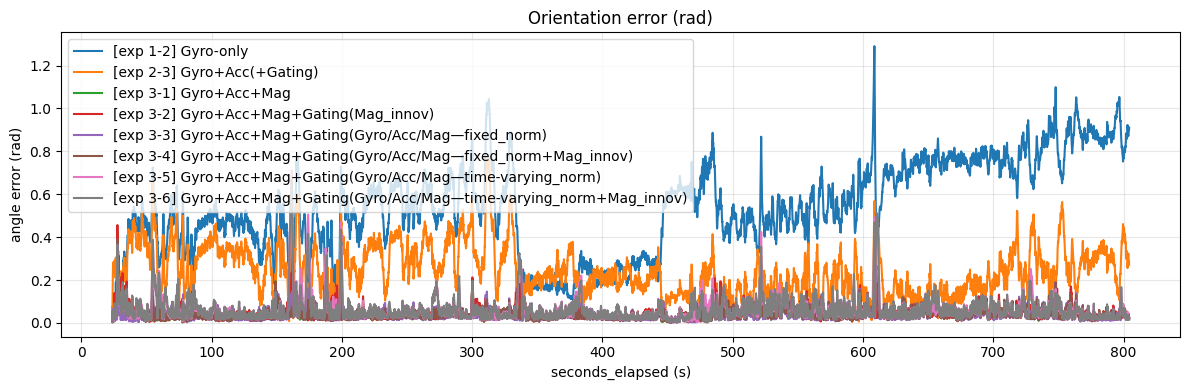

In [47]:
save_err_csv(path_err_1, t_new, angle_err_1)
save_err_csv(path_err_2, t_new, angle_err_2)
save_err_csv(path_err_3, t_new, angle_err_3)
save_err_csv(path_err_4, t_new, angle_err_4)
save_err_csv(path_err_5, t_new, angle_err_5)
save_err_csv(path_err_6, t_new, angle_err_6)

best_exp2 = read_best_exp2_from_log(out_dir / "02_exp2_log.txt")
path_err_exp1_2 = out_dir / "01_exp1-2_angle_err.csv"
path_err_best_exp2 = out_dir / f"02_exp{best_exp2}_angle_err.csv"

plot_err_from_csv([
        ("[exp 1-2] Gyro-only", path_err_exp1_2),
        (f"[exp {best_exp2}] Gyro+Acc(+Gating)", path_err_best_exp2),
        ("[exp 3-1] Gyro+Acc+Mag", path_err_1),
        ("[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov)", path_err_2),
        ("[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm)", path_err_3),
        ("[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov)", path_err_4),
        ("[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)", path_err_5),
        ("[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)", path_err_6)],
                  path_plot)

In [48]:
def err_score_mean_p90(err: ScalarBatch) -> float:
        mean: float = np.mean(err)
        p90: float = np.percentile(err, 90)
        return 0.8 * mean + 0.2 * p90

In [49]:
with Tee(path_log):
        best: Data = None
        for i in [data_exp1, data_exp2, data_exp3, data_exp4, data_exp5, data_exp6]:
                if best is None or err_score_mean_p90(i.angle_err) < err_score_mean_p90(best.angle_err):
                        best = i

        s: str = best.exp
        s = s[s.find('-')-1 : s.find('-')+2]
        print(f"best: exp{s}")

        [min_angle_err,
         w_acc, w_gyro, w_mag,
         w_total,
         g_est, a_est
         ] = [best.angle_err,
              best.weight_acc, best.weight_gyro, best.weight_mag,
              best.weight_acc*best.weight_gyro + best.mag_gain*best.weight_mag,
              best.g_body_est, best.a_lin_est]



[START] 2026-03-16 18:07:04.167

best: exp3-3

[END] 2026-03-16 18:07:04.182




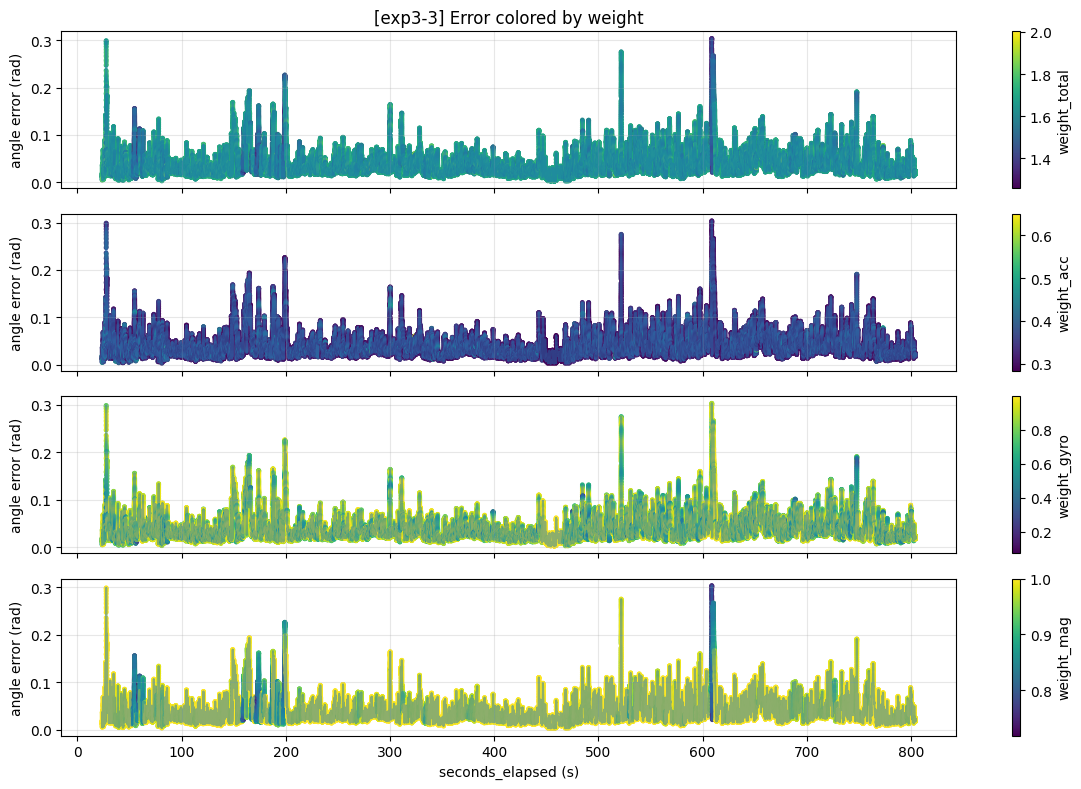

In [50]:
plot_err_colored_by_weight(3, t_new, min_angle_err,
                           w_acc, w_gyro, w_mag, w_total,
                           best.exp, path_plot_weight)

In [51]:
with Tee(path_log):
        print("[Gravity]")
        g_est_sign_fixed, g_rmse_norm = evaluate_estimated_vec3_autosign(g_est, g_ref_interp)
        save_estimated_vec3_csv(path_est_grav, t_new, g_est_sign_fixed)
        err_grav = calc_vec3_direction_angle_err(g_est_sign_fixed, g_ref_interp)
        print("")
        print_err_status("Gravity est/ref", err_grav)
        print("")

        print("\n[Linear accel]")
        a_lin_est_sign_fixed, a_lin_rmse_norm = evaluate_estimated_vec3_autosign(a_est, a_lin_ref_interp)
        save_estimated_vec3_csv(path_est_acc, t_new, a_lin_est_sign_fixed)
        err_acc_lin = calc_vec3_direction_angle_err(a_lin_est_sign_fixed, a_lin_ref_interp)
        print("")
        print_err_status("Linear accel est/ref", err_acc_lin)
        print("")

        print("\n[Consistency ratio]")
        print("rmse_norm of (a_lin_est / g_est): ", a_lin_rmse_norm / max(g_rmse_norm, EPS))



[START] 2026-03-16 18:07:23.266

[Gravity]
RMSE norm: 0.1800490753281907

Gravity est/ref angle error in rad — min/max/mean/p90
6.344569720577262e-05 0.03952086951592452 0.01761454253787616 0.024120060778194733

Gravity est/ref angle error in deg — min/max/mean/p90
0.0036351706781557313 2.2643790259497076 1.009238945473962 1.3819776841895903


[Linear accel]
RMSE norm: 0.5500461373406331

Linear accel est/ref angle error in rad — min/max/mean/p90
0.00023568751622905288 2.728179621257335 0.11840303812910537 0.27423599127868414

Linear accel est/ref angle error in deg — min/max/mean/p90
0.013503899963845826 156.31317805164468 6.7839943663243005 15.712564890855054


[Consistency ratio]
rmse_norm of (a_lin_est / g_est):  3.0549789624746335

[END] 2026-03-16 18:07:24.349


